In [64]:
## load the koo-model ISM (saturation-mutagenesis) maps for a random sequence
# gradient-corrected (mean-centered across channels) — analog of hypothetical DeepLIFT
# high-activity HepG2 example: HepG2_activating_0
import h5py
import numpy as np
import matplotlib.pyplot as plt
import logomaker
import pandas as pd

seam_dir = "/grid/koo/home/pmantill/projects/Virtual_Experiments/MoConSwap_mpra/SEAM_jointlib900/results"
condition, seq_idx = "HepG2_activating", 0

with h5py.File(f"{seam_dir}/ism_var200/HepG2/{condition}_{seq_idx}.h5") as f:
    attributions = f["ism_centered"][:]   # (N, 200, 4) ISM, mean-centered across channels
    predictions  = f["predictions"][:]    # (N,) self-prediction of each base sequence

with h5py.File(f"{seam_dir}/mutagenesis_lib_var200/{condition}_{seq_idx}.h5") as f:
    sequences   = f["sequences"][:]       # (N, 200, 4); index 0 is WT
    wt_sequence = f["wt_sequence"][:]     # (230, 4) with 15bp adapters

wt_onehot = wt_sequence[15:215]           # variable region matches attributions axis
wt_attr   = attributions[0]               # WT attribution map (ISM-centered)

In [65]:
print(f"{attributions.shape[0]:,} attribution maps  |  shape per map: {attributions.shape[1:]}")

25,000 attribution maps  |  shape per map: (200, 4)


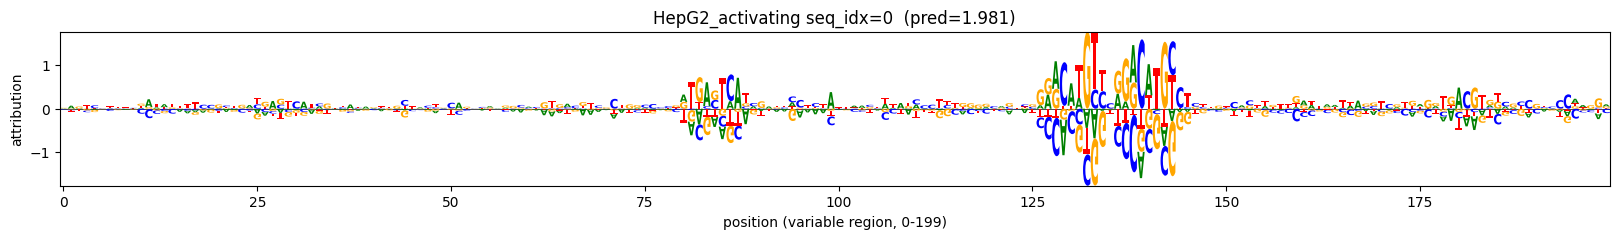

In [66]:
## visualize wt logo
wt_logo = pd.DataFrame(wt_attr, columns=list("ACGT"))

fig, ax = plt.subplots(figsize=(20, 2))
logomaker.Logo(wt_logo, ax=ax)
ax.set_xlabel("position (variable region, 0-199)")
ax.set_ylabel("attribution")
ax.set_title(f"{condition} seq_idx={seq_idx}  (pred={predictions[0]:.3f})")
plt.show()

In [67]:
from scipy.special import digamma, gammaln, logsumexp

X = attributions.reshape(attributions.shape[0], -1)   # (N, 4L)
N, D = X.shape
print(f"N={N:,}  D={D}  (=4*{D//4})")

def log_gauss_diag(X, mu, log_var, X2=None):
    # expanded mahalanobis: avoids the (N,K,D) intermediate. accepts cached X2 = X**2.
    if X2 is None: X2 = X**2
    precision = np.exp(-log_var)                              # (K, D)
    log_norm  = -0.5 * (np.log(2*np.pi) + log_var).sum(-1)    # (K,)
    mahal     = (X2 @ precision.T
                 - 2 * X @ (mu * precision).T
                 + (mu**2 * precision).sum(-1))               # (N, K)
    return log_norm - 0.5 * mahal

def kl_dirichlet(alpha, alpha0, Elog_pi):
    K = len(alpha)
    return (gammaln(alpha.sum()) - gammaln(alpha).sum()
            - gammaln(K * alpha0) + K * gammaln(alpha0)
            + ((alpha - alpha0) * Elog_pi).sum())

def elbo_from_logunnorm(log_unnorm, alpha, alpha0, Elog_pi):
    # after E-step, log p_old(x) (variational-pi version) = logsumexp(log_unnorm), no extra log_gauss_diag.
    return logsumexp(log_unnorm, axis=1).sum() - kl_dirichlet(alpha, alpha0, Elog_pi)

N=25,000  D=800  (=4*200)


In [68]:
K, alpha0 = 100, 1e-10                                       # over-complete; low alpha0 -> prune
rng = np.random.default_rng(0)

alpha   = np.full(K, alpha0 + N / K)                        # init q(pi) ~ uniform
mu      = X[rng.choice(N, K, replace=False)].copy()         # K data points
log_var = np.full((K, D), np.log(X.var(0).mean() + 1e-8))

# E-step: log r_nk = E[log pi_k] + log N(x_n; mu_k, sigma_k^2)  (normalized)
Elog_pi    = digamma(alpha) - digamma(alpha.sum())
log_unnorm = log_gauss_diag(X, mu, log_var) + Elog_pi
log_r      = log_unnorm - logsumexp(log_unnorm, axis=1, keepdims=True)
r          = np.exp(log_r)

elbo_step1 = elbo_from_logunnorm(log_unnorm, alpha, alpha0, Elog_pi)

# M-step (MLE; np.maximum floor only to dodge FP-noise log() on tiny Nk clusters)
Nk      = r.sum(0)
alpha   = alpha0 + Nk                                       # q(pi) update
safe    = np.clip(Nk, 1e-8, None)[:, None]
mu      = (r.T @ X) / safe
log_var = np.log(np.maximum((r.T @ (X**2)) / safe - mu**2, 1e-8))

print(f"ELBO after 1 VB step: {elbo_step1:.3f}")

ELBO after 1 VB step: 19734773.506


converged in 200 iters  |  active clusters: 92/100  |  final ELBO: 30417098.830


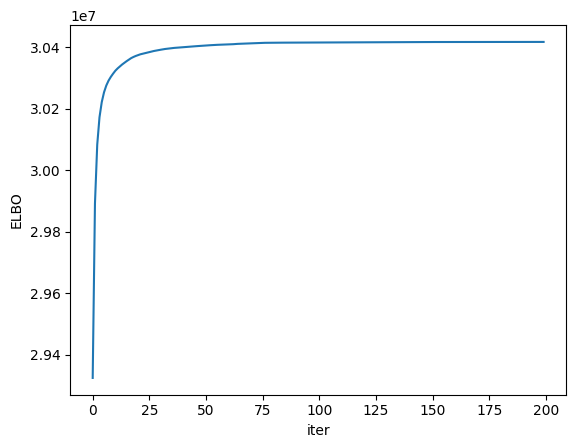

In [69]:
# repeat VB-EM until convergence
X2 = X**2                                    # cache once: used in E- and M-steps
losses = []

for it in range(200):
    # E-step
    Elog_pi    = digamma(alpha) - digamma(alpha.sum())
    log_unnorm = log_gauss_diag(X, mu, log_var, X2=X2) + Elog_pi
    log_r      = log_unnorm - logsumexp(log_unnorm, axis=1, keepdims=True)
    r          = np.exp(log_r)

    losses.append(elbo_from_logunnorm(log_unnorm, alpha, alpha0, Elog_pi))

    # M-step
    Nk      = r.sum(0)
    alpha   = alpha0 + Nk
    safe    = np.clip(Nk, 1e-8, None)[:, None]
    mu      = (r.T @ X)  / safe
    log_var = np.log(np.maximum((r.T @ X2) / safe - mu**2, 1e-8))

    if it > 0 and abs(losses[-1] - losses[-2]) < 1e-3:
        break

active = int((Nk > 1).sum())
print(f"converged in {len(losses)} iters  |  active clusters: {active}/{K}  |  final ELBO: {losses[-1]:.3f}")
plt.plot(losses); plt.xlabel("iter"); plt.ylabel("ELBO"); plt.show()

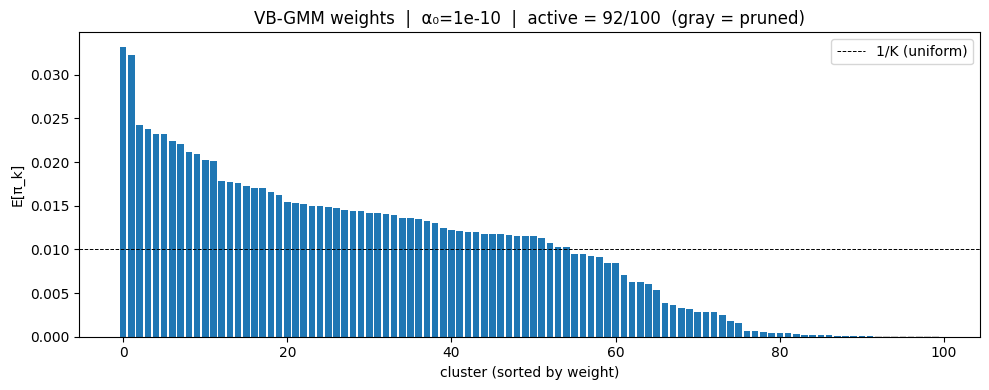

,Nk,alpha,E_pi,active
27,1.0,1.000,0.0000,False
21,1.0,1.000,0.0000,False
56,1.0,1.000,0.0000,False
33,1.0,1.000,0.0000,False
99,1.0,1.000,0.0000,False
89,1.0,1.000,0.0000,False
87,1.0,1.000,0.0000,False
77,1.0,1.000,0.0000,False
22,2.0,2.000,0.0001,True
88,2.0,2.000,0.0001,True


In [70]:
## cluster weights — visualize pruning
E_pi  = alpha / alpha.sum()                          # E_q[pi_k]
order = np.argsort(-E_pi)
active_mask = (Nk > 1)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["C0" if active_mask[k] else "lightgray" for k in order]
ax.bar(range(K), E_pi[order], color=colors)
ax.axhline(1/K, ls="--", c="k", lw=0.7, label="1/K (uniform)")
ax.set_xlabel("cluster (sorted by weight)")
ax.set_ylabel("E[π_k]")
ax.set_title(f"VB-GMM weights  |  α₀={alpha0}  |  active = {int(active_mask.sum())}/{K}  (gray = pruned)")
ax.legend(); plt.tight_layout(); plt.show()

with pd.option_context("display.max_rows", None):
    display(pd.DataFrame({
        "Nk":     Nk.round(1),
        "alpha":  alpha.round(3),
        "E_pi":   E_pi.round(4),
        "active": active_mask,
    }).sort_values("Nk", ascending=True))

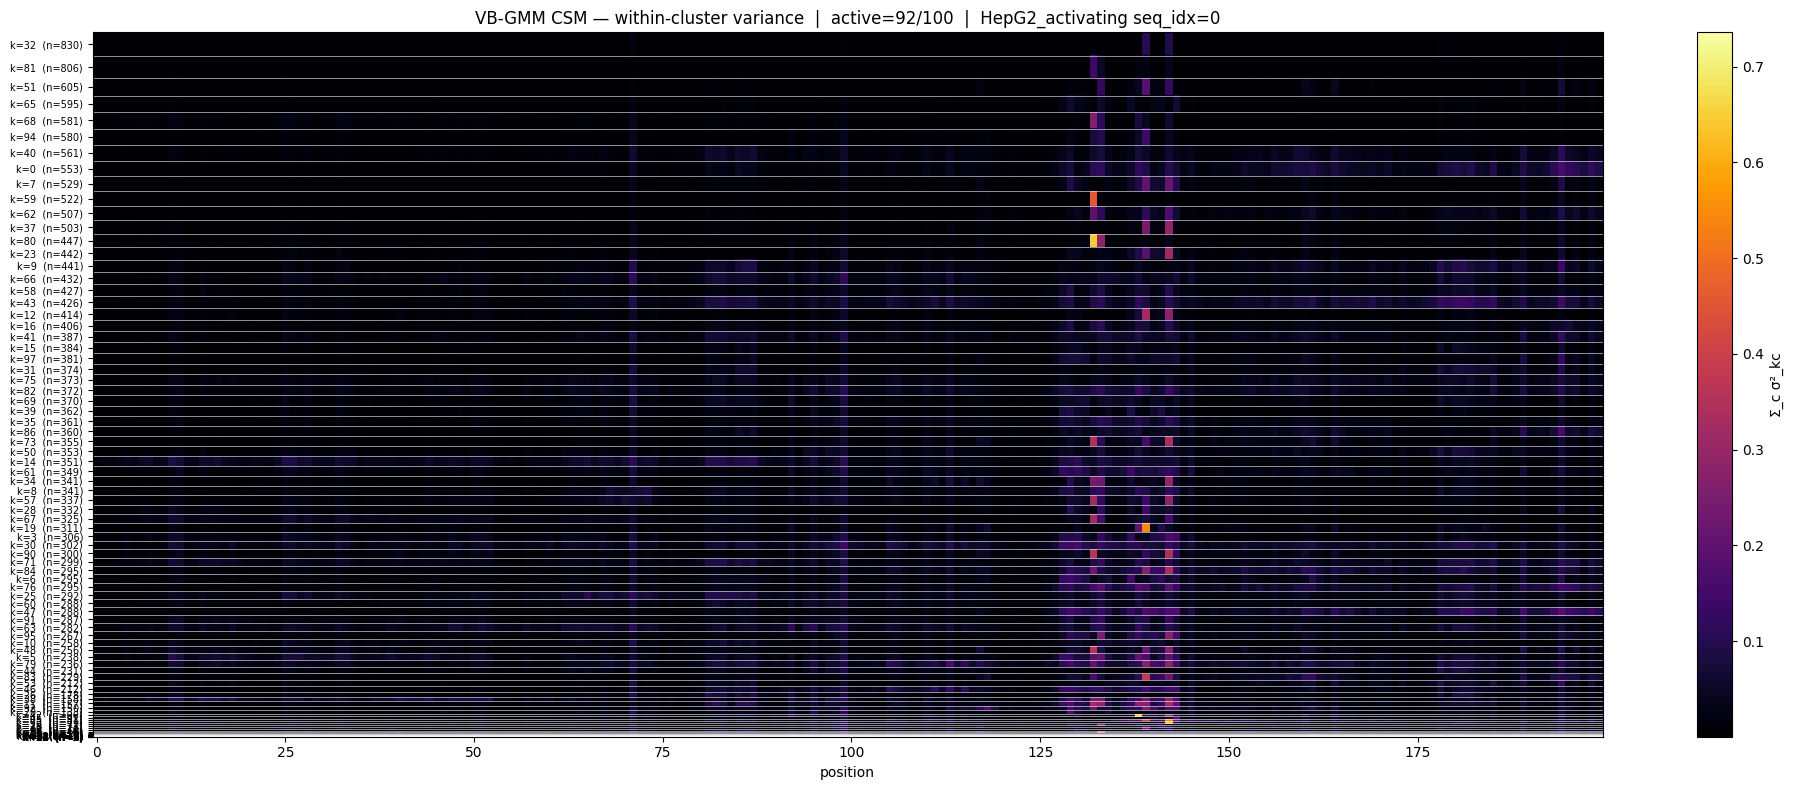

In [71]:
## CSM: rows = seqs in active clusters, ordered by cluster size (largest first), color = within-cluster variance (Σ over channels)
hard         = log_r.argmax(1)
active       = np.where(Nk > 1)[0]
ranked       = active[np.argsort(-Nk[active])]               # active clusters, largest first
counts       = np.bincount(hard, minlength=K)

var_maps     = np.exp(log_var).reshape(K, D // 4, 4)
var_per_kpos = var_maps.sum(-1)                              # (K, L)

rank_of      = {int(k): i for i, k in enumerate(ranked)}
mask         = np.isin(hard, ranked)
idx          = np.where(mask)[0]
sub_rank     = np.array([rank_of[int(h)] for h in hard[idx]])
row_order    = idx[np.argsort(sub_rank, kind="stable")]
mat          = var_per_kpos[hard[row_order]]                 # (Σ_active counts, L)

block_sizes  = [counts[k] for k in ranked]
boundaries   = np.cumsum(block_sizes)[:-1]
yticks       = np.cumsum([0] + block_sizes[:-1]) + np.array(block_sizes) / 2
ylabels      = [f"k={k}  (n={counts[k]})" for k in ranked]

fig, ax = plt.subplots(figsize=(20, 8))
im = ax.imshow(mat, aspect="auto", cmap="inferno", interpolation="nearest")
for b in boundaries:
    ax.axhline(b, color="w", lw=0.4)
ax.set_yticks(yticks); ax.set_yticklabels(ylabels, fontsize=7)
ax.set_xlabel("position")
ax.set_title(f"VB-GMM CSM — within-cluster variance  |  active={len(ranked)}/{K}  |  {condition} seq_idx={seq_idx}")
plt.colorbar(im, ax=ax, label="Σ_c σ²_kc"); plt.tight_layout(); plt.show()

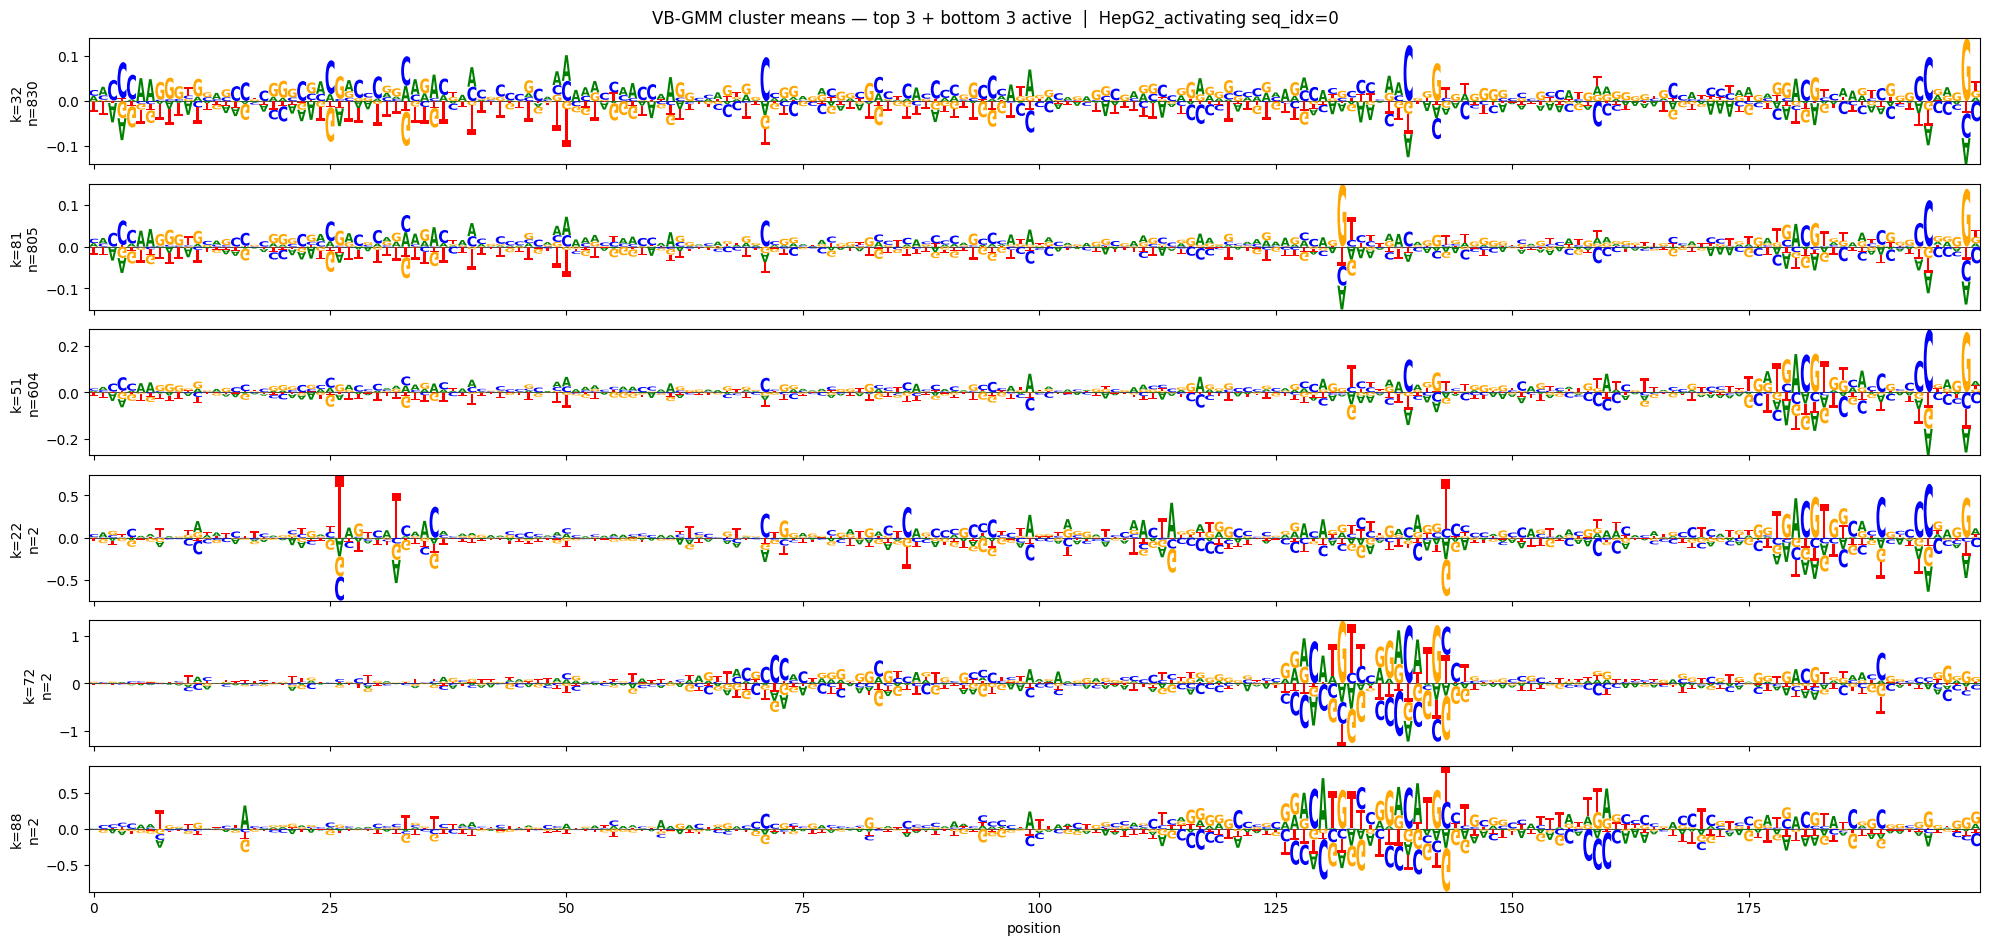

In [72]:
## logos for top-3 and bottom-3 active clusters by Nk
mu_maps    = mu.reshape(K, D // 4, 4)
active_idx = np.where(Nk > 1)[0]
ranked     = active_idx[np.argsort(-Nk[active_idx])]         # active, largest first
order      = np.concatenate([ranked[:3], ranked[-3:]]) if len(ranked) >= 6 else ranked

fig, axes = plt.subplots(len(order), 1, figsize=(20, 1.6 * len(order)), sharex=True)
if len(order) == 1: axes = [axes]
for ax, k in zip(axes, order):
    logomaker.Logo(pd.DataFrame(mu_maps[k], columns=list("ACGT")), ax=ax)
    ax.set_ylabel(f"k={k}\nn={int(Nk[k])}")
axes[-1].set_xlabel("position")
fig.suptitle(f"VB-GMM cluster means — top 3 + bottom 3 active  |  {condition} seq_idx={seq_idx}")
plt.tight_layout(); plt.show()

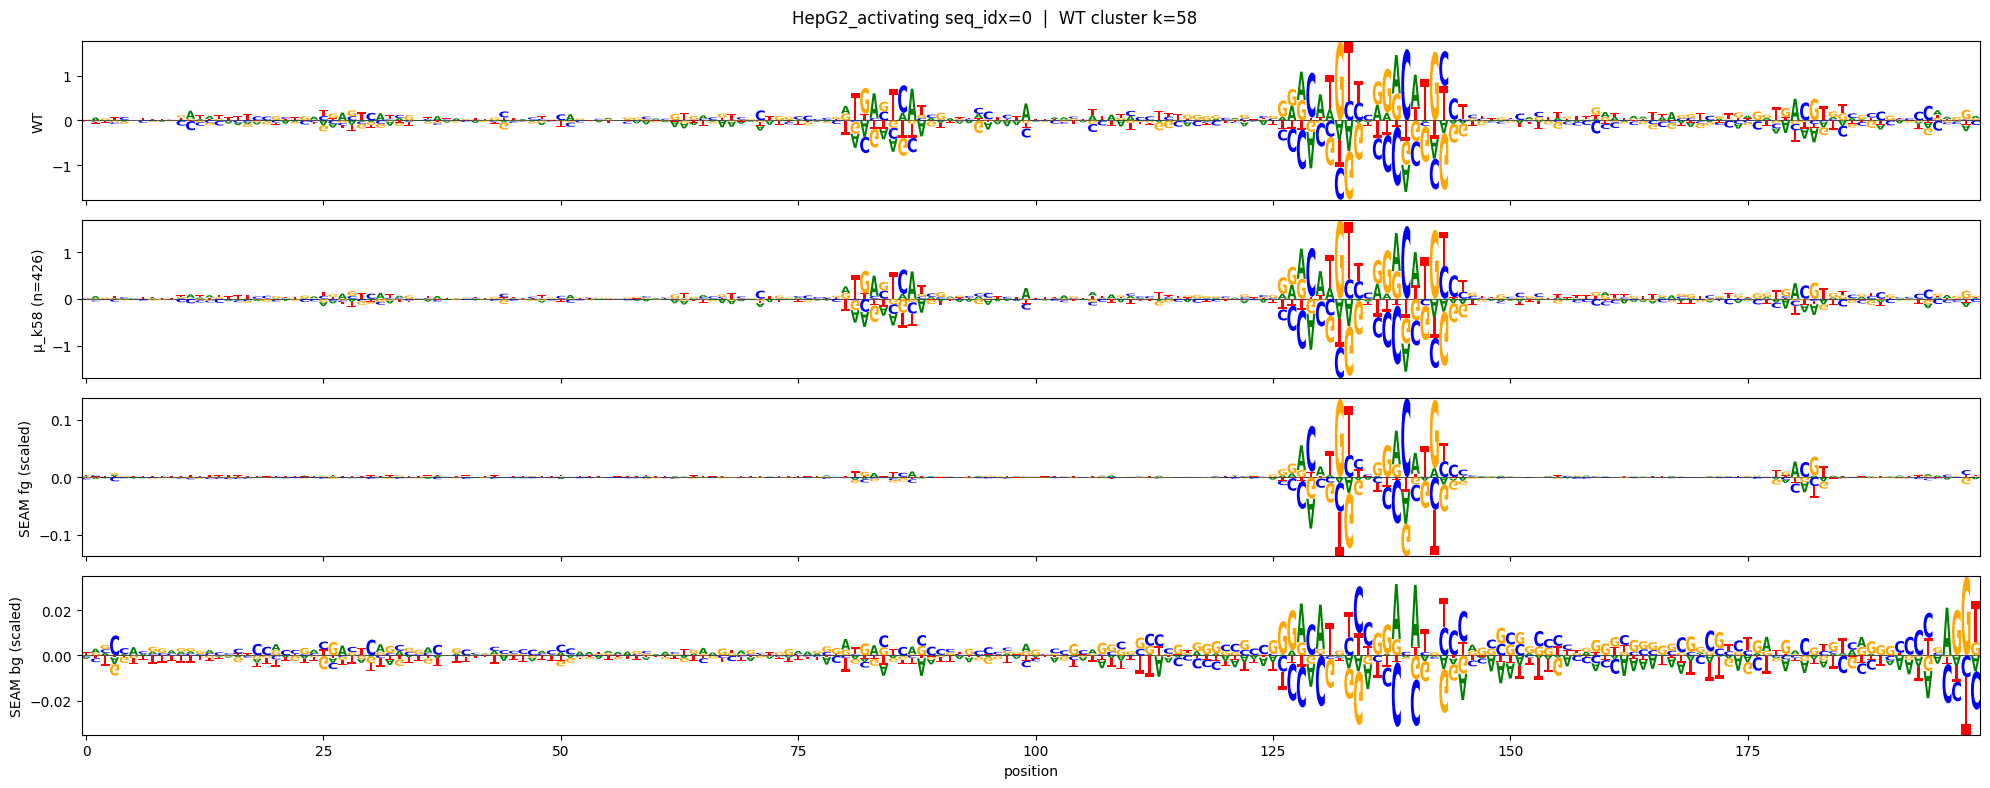

In [73]:
## WT  |  its VB-GMM cluster mean (candidate fg)  |  SEAM fg  |  SEAM bg (scaled)
k_wt = int(log_r[0].argmax())

seam_fg = np.load(f"{seam_dir}/foregrounds_var200/HepG2/{seq_idx}/foreground_scaled.npy")
seam_bg = np.load(f"{seam_dir}/foregrounds_var200/HepG2/{seq_idx}/average_background_scaled.npy")

fig, axes = plt.subplots(4, 1, figsize=(20, 8), sharex=True)
for ax, mat, lbl in zip(
    axes,
    [wt_attr, mu_maps[k_wt], seam_fg, seam_bg],
    ["WT", f"μ_k{k_wt} (n={int(Nk[k_wt])})", "SEAM fg (scaled)", "SEAM bg (scaled)"],
):
    logomaker.Logo(pd.DataFrame(mat, columns=list("ACGT")), ax=ax)
    ax.set_ylabel(lbl)
axes[-1].set_xlabel("position")
fig.suptitle(f"{condition} seq_idx={seq_idx}  |  WT cluster k={k_wt}")
plt.tight_layout(); plt.show()

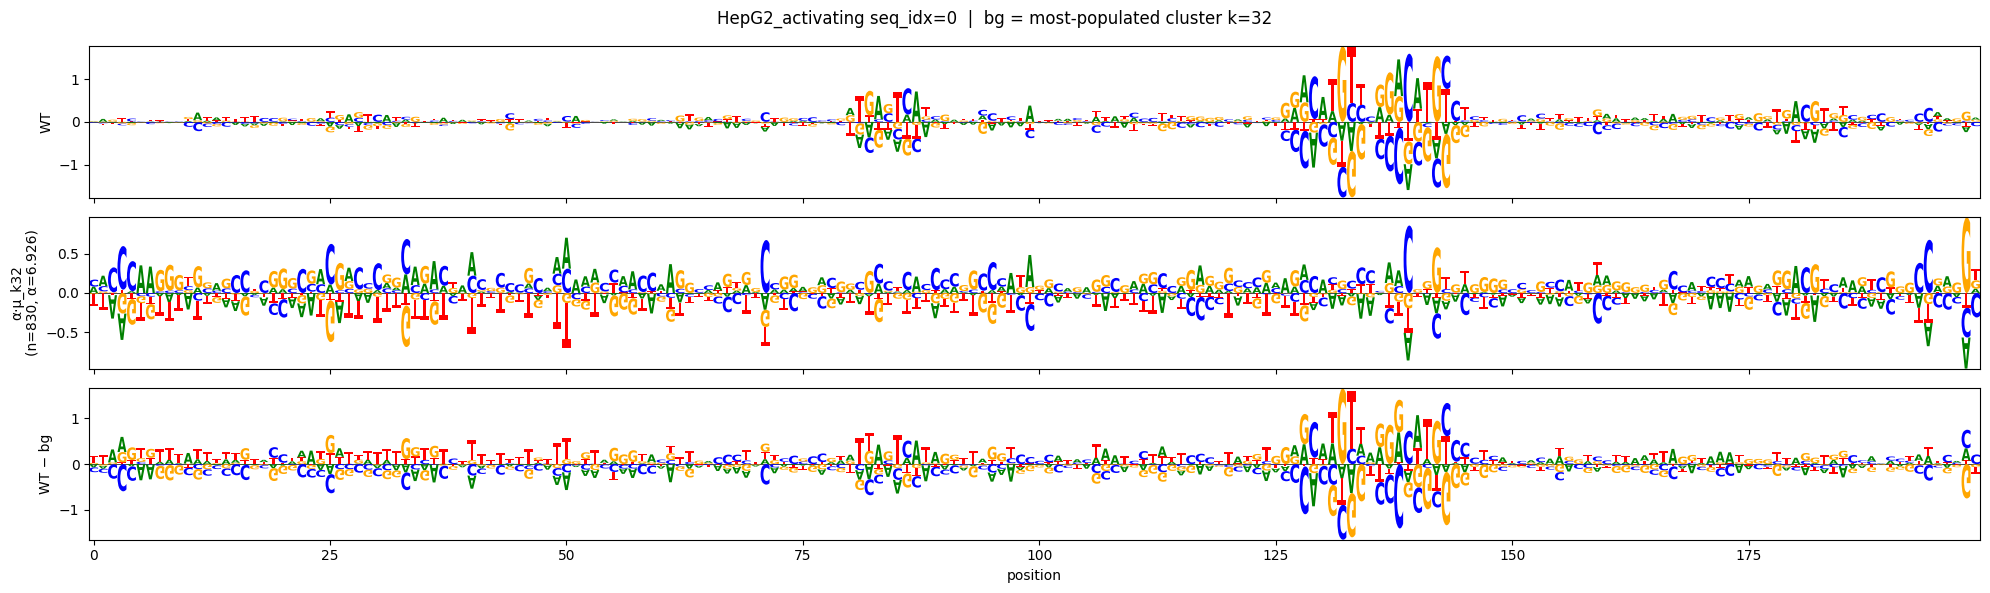

In [76]:
## WT − scaled most-populated cluster mean (α = L1 ratio over all positions)
k_bg      = int(np.argmax(Nk))
bg        = mu_maps[k_bg]
alpha     = np.abs(wt_attr).sum() / (np.abs(bg).sum() + 1e-12)
bg_scaled = alpha * bg
resid     = wt_attr - bg_scaled

fig, axes = plt.subplots(3, 1, figsize=(20, 6), sharex=True)
logomaker.Logo(pd.DataFrame(wt_attr,   columns=list("ACGT")), ax=axes[0])
logomaker.Logo(pd.DataFrame(bg_scaled, columns=list("ACGT")), ax=axes[1])
logomaker.Logo(pd.DataFrame(resid,     columns=list("ACGT")), ax=axes[2])
axes[0].set_ylabel("WT")
axes[1].set_ylabel(f"α·μ_k{k_bg}\n(n={int(Nk[k_bg])}, α={alpha:.3f})")
axes[2].set_ylabel("WT − bg")
axes[-1].set_xlabel("position")
fig.suptitle(f"{condition} seq_idx={seq_idx}  |  bg = most-populated cluster k={k_bg}")
plt.tight_layout(); plt.show()